In [2]:
import numpy as np
import pandas as pd
import re #regular expression
from nltk.corpus import stopwords
#nltk--> natural language toolkit
from nltk.stem.porter import PorterStemmer #provides rrooot word
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Clean the raw text:

Lowercasing
"Hello WORLD" → "hello world"

Removing noise

Punctuation, special characters, digits if not useful

e.g. "Hello, bro!!!" → "Hello bro"

Tokenization
Split text into words or subwords
"I love Python" → ["I", "love", "Python"]

Stopword removal
Remove common words with little meaning (like “the”, “is”, “of”)
["I", "love", "Python"] → ["love", "Python"]

Stemming / Lemmatization
Reduce words to their root/base form:

Stemming: "running" → "run" (rough cut)

Lemmatization: "better" → "good" (linguistic base)

Handling emojis, hashtags, URLs (for social media data)

Spelling correction / normalization if needed

In [3]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\latha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [5]:
news_dataset=pd.read_csv("fake[1].csv")

In [6]:
news_dataset.shape

(23481, 4)

In [7]:
news_dataset.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [9]:
truedata= pd.read_csv("true[1].csv")

In [10]:
truedata.shape

(21417, 4)

In [11]:
truedata.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [12]:
truedata.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [13]:
news_dataset.isnull().sum()

title      0
text       0
subject    0
date       0
dtype: int64

In [15]:
data=pd.concat([truedata,news_dataset],ignore_index=True)
data.to_csv('merged_news.csv',index=False)

In [16]:
df=pd.read_csv("merged_news.csv")

In [17]:
df.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44898 entries, 0 to 44897
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    44898 non-null  object
 1   text     44898 non-null  object
 2   subject  44898 non-null  object
 3   date     44898 non-null  object
dtypes: object(4)
memory usage: 1.4+ MB


In [19]:
df['text_cleaned'] = df['text'].str.lower().str.replace(r'[^\w\s]', '', regex=True)#remove everything except letters, digits, and spaces
df['title_cleaned'] = df['title'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

In [21]:
#[^abc] matches any character except a, b, or c.   replace(r'[^\w\s]',""
#^ → negation

#\w → word characters

#\s → whitespace

In [22]:
df.head()

,title,text,subject,date,text_cleaned,title_cleaned
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",washington reuters the head of a conservative...,as us budget fight looms republicans flip thei...
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",washington reuters transgender people will be...,us military to accept transgender recruits on ...
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",washington reuters the special counsel invest...,senior us republican senator let mr mueller do...
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",washington reuters trump campaign adviser geo...,fbi russia probe helped by australian diplomat...
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",seattlewashington reuters president donald tr...,trump wants postal service to charge much more...


In [23]:
df['tokenized_text'] = df['text_cleaned'].apply(lambda x: x.split())

In [24]:
df.head()

,title,text,subject,date,text_cleaned,title_cleaned,tokenized_text
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",washington reuters the head of a conservative...,as us budget fight looms republicans flip thei...,"[washington, reuters, the, head, of, a, conser..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",washington reuters transgender people will be...,us military to accept transgender recruits on ...,"[washington, reuters, transgender, people, wil..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",washington reuters the special counsel invest...,senior us republican senator let mr mueller do...,"[washington, reuters, the, special, counsel, i..."
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",washington reuters trump campaign adviser geo...,fbi russia probe helped by australian diplomat...,"[washington, reuters, trump, campaign, adviser..."
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",seattlewashington reuters president donald tr...,trump wants postal service to charge much more...,"[seattlewashington, reuters, president, donald..."


In [25]:


stop_words = set(stopwords.words('english'))

df['text_without_stopwords'] = df['tokenized_text'].apply(
    lambda words: [word for word in words if word not in stop_words]
)

df[['tokenized_text', 'text_without_stopwords']].head()

,tokenized_text,text_without_stopwords
0,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu..."
1,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all..."
2,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest..."
3,"[washington, reuters, trump, campaign, adviser...","[washington, reuters, trump, campaign, adviser..."
4,"[seattlewashington, reuters, president, donald...","[seattlewashington, reuters, president, donald..."


In [26]:
df['token_count_before'] = df['tokenized_text'].str.len()
df['token_count_after'] = df['text_without_stopwords'].str.len()

df[['tokenized_text', 'text_without_stopwords', 'token_count_before', 'token_count_after']].head()

,tokenized_text,text_without_stopwords,token_count_before,token_count_after
0,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu...",745,454
1,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all...",621,383
2,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest...",456,264
3,"[washington, reuters, trump, campaign, adviser...","[washington, reuters, trump, campaign, adviser...",375,230
4,"[seattlewashington, reuters, president, donald...","[seattlewashington, reuters, president, donald...",851,510


In [27]:
tfidf = TfidfVectorizer( ngram_range=(1,1),max_features=5000)
#TfidfVectorizer: Converts text into TF-IDF (Term Frequency–Inverse Document Frequency) vectors — i.e., numerical features representing how important each word is in a document relative to all documents.
tfidftitle = TfidfVectorizer( ngram_range=(1,1),max_features=5000)
#Use only unigrams (single words).

#Example: "fake news spreads fast" → tokens: "fake", "news", "spreads", "fast".
text_tfidf = tfidf.fit_transform(df['text_without_stopwords'].astype(str))
title_tfidf = tfidftitle.fit_transform(df['title_cleaned'].astype(str))

In [28]:
df['body_length'] = df['text'].apply(lambda x: len(x)-x.count(' ') )
df['title_length'] = df['title'].apply(lambda x: len(x)-x.count(' ') )

df.head()

,title,text,subject,date,text_cleaned,title_cleaned,tokenized_text,text_without_stopwords,token_count_before,token_count_after,body_length,title_length
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",washington reuters the head of a conservative...,as us budget fight looms republicans flip thei...,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu...",745,454,3907,55
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",washington reuters transgender people will be...,us military to accept transgender recruits on ...,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all...",621,383,3453,56
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",washington reuters the special counsel invest...,senior us republican senator let mr mueller do...,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest...",456,264,2324,51
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",washington reuters trump campaign adviser geo...,fbi russia probe helped by australian diplomat...,"[washington, reuters, trump, campaign, adviser...","[washington, reuters, trump, campaign, adviser...",375,230,2085,51
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",seattlewashington reuters president donald tr...,trump wants postal service to charge much more...,"[seattlewashington, reuters, president, donald...","[seattlewashington, reuters, president, donald...",851,510,4341,59


In [31]:
import nltk
from nltk.stem import WordNetLemmatizer   

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

df['text_lemmatized'] = df['text_without_stopwords'].apply(
    lambda words: [lemmatizer.lemmatize(w) for w in words]
)


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\latha\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\latha\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [32]:
df[['text_without_stopwords', 'text_lemmatized']].head()


,text_without_stopwords,text_lemmatized
0,"[washington, reuters, head, conservative, repu...","[washington, reuters, head, conservative, repu..."
1,"[washington, reuters, transgender, people, all...","[washington, reuters, transgender, people, all..."
2,"[washington, reuters, special, counsel, invest...","[washington, reuters, special, counsel, invest..."
3,"[washington, reuters, trump, campaign, adviser...","[washington, reuters, trump, campaign, adviser..."
4,"[seattlewashington, reuters, president, donald...","[seattlewashington, reuters, president, donald..."


In [33]:
df.head()

,title,text,subject,date,text_cleaned,title_cleaned,tokenized_text,text_without_stopwords,token_count_before,token_count_after,body_length,title_length,text_lemmatized
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",washington reuters the head of a conservative...,as us budget fight looms republicans flip thei...,"[washington, reuters, the, head, of, a, conser...","[washington, reuters, head, conservative, repu...",745,454,3907,55,"[washington, reuters, head, conservative, repu..."
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",washington reuters transgender people will be...,us military to accept transgender recruits on ...,"[washington, reuters, transgender, people, wil...","[washington, reuters, transgender, people, all...",621,383,3453,56,"[washington, reuters, transgender, people, all..."
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",washington reuters the special counsel invest...,senior us republican senator let mr mueller do...,"[washington, reuters, the, special, counsel, i...","[washington, reuters, special, counsel, invest...",456,264,2324,51,"[washington, reuters, special, counsel, invest..."
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",washington reuters trump campaign adviser geo...,fbi russia probe helped by australian diplomat...,"[washington, reuters, trump, campaign, adviser...","[washington, reuters, trump, campaign, adviser...",375,230,2085,51,"[washington, reuters, trump, campaign, adviser..."
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",seattlewashington reuters president donald tr...,trump wants postal service to charge much more...,"[seattlewashington, reuters, president, donald...","[seattlewashington, reuters, president, donald...",851,510,4341,59,"[seattlewashington, reuters, president, donald..."


In [35]:
truedata['label'] = 1
news_dataset['label'] = 0

df = pd.concat([truedata, news_dataset], ignore_index=True)

X = text_tfidf
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (35918, 5000)
Shape of X_test: (8980, 5000)
Shape of y_train: (35918,)
Shape of y_test: (8980,)


In [40]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import nltk as nltk
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
import re
from nltk.stem import WordNetLemmatizer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
y_pred_lr = lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred_lr)
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Model Evaluation:")
print("Mean Squared Error (MSE):", mse)
print("R-squared Score (R2):", r2)

Linear Regression Model Evaluation:
Mean Squared Error (MSE): 0.028623641130069488
R-squared Score (R2): 0.8853598614226698


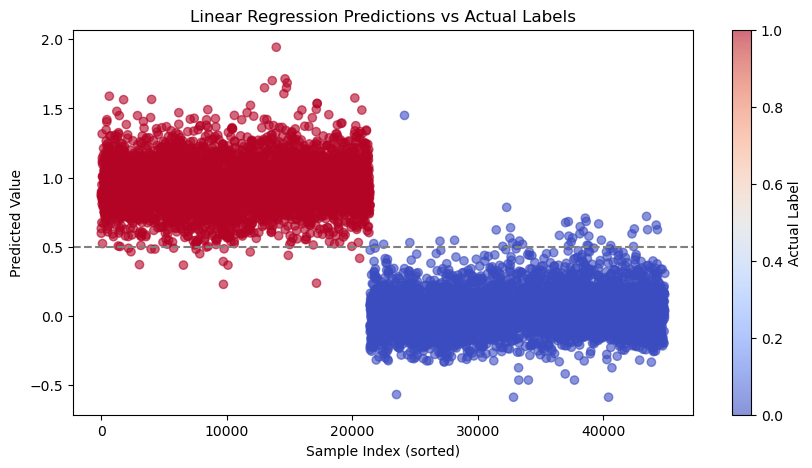

In [45]:
plot_df_lr = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred_lr})
plot_df_lr = plot_df_lr.sort_values('Predicted')
plt.figure(figsize=(10, 5))
plt.scatter(plot_df_lr.index, plot_df_lr['Predicted'], c=plot_df_lr['Actual'], cmap='coolwarm', alpha=0.6)
plt.axhline(0.5, color='gray', linestyle='--')
plt.title('Linear Regression Predictions vs Actual Labels')
plt.xlabel('Sample Index (sorted)')
plt.ylabel('Predicted Value')
plt.colorbar(label='Actual Label')
plt.show()

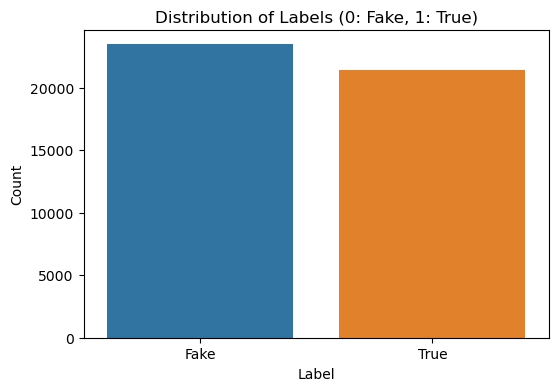

In [46]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Distribution of Labels (0: Fake, 1: True)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks([0, 1], ['Fake', 'True'])
plt.show()